In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

### Convolutional Encoder

Hierarchical feature extractor for image inputs using progressive downsampling.

- **Architecture:**
  - 4 convolutional blocks
  - Each block:
    - Conv → ReLU → Conv (stride=2) → ReLU
  - Spatial resolution reduced by factor of 2 at each stage

- **Feature Hierarchy:**
  - $(B, C, 64, 64) \rightarrow (B, 64, 32, 32)$  
  - $(B, 64, 32, 32) \rightarrow (B, 128, 16, 16)$  
  - $(B, 128, 16, 16) \rightarrow (B, 256, 8, 8)$  
  - $(B, 256, 8, 8) \rightarrow (B, 512, 4, 4)$  

- **Output:**
  - Returns multi-scale feature maps: $(x_1, x_2, x_3, x_4)$

- Captures increasingly abstract spatial features, useful for skip connections in U-Net style architectures.

In [2]:
class encoder(nn.Module):
    def __init__(self,input_dim):
        super().__init__()

        self.input_dim = input_dim
        
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(self.input_dim, 64, kernel_size=3, padding=1),  # (B, 3, 64, 64) -> (B, 64, 64, 64)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),    # (B, 64, 64, 64) -> (B, 64, 32, 32)
            nn.ReLU()
        )
        
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),             # (B, 64, 32, 32) -> (B, 128, 32, 32)
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1),  # (B, 128, 32, 32) -> (B, 128, 16, 16)
            nn.ReLU()
        )
        
        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),            # (B, 128, 16, 16) -> (B, 256, 16, 16)
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1),  # (B, 256, 16, 16) -> (B, 256, 8, 8)
            nn.ReLU()
        )
        
        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),            # (B, 256, 8, 8) -> (B, 512, 8, 8)
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1),  # (B, 512, 8, 8) -> (B, 512, 4, 4)
            nn.ReLU()
        )
        
    def forward(self, x):
        x1 = self.block1(x)  # (B, 3, 64, 64) -> (B, 64, 32, 32)
        x2 = self.block2(x1)  # (B, 64, 32, 32) -> (B, 128, 16, 16)
        x3 = self.block3(x2)  # (B, 128, 16, 16) -> (B, 256, 8, 8)
        x4 = self.block4(x3)  # (B, 256, 8, 8) -> (B, 512, 4, 4)
        return x1,x2,x3,x4

### Bridge (Bottleneck Layer)

Intermediate layer connecting encoder and decoder.

- **Operation:**
  - Single $3 \times 3$ convolution

- **Input / Output:**
  - $(B, 512, 4, 4) \rightarrow (B, 512, 4, 4)$

- Acts as a bottleneck to refine high-level features before upsampling.

- Provides additional feature transformation at the lowest spatial resolution.

In [3]:
class bridge(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(512, 512, kernel_size=3,padding=1)
        
    def forward(self,x):
        x = self.conv1(x)
        return x        

### Decoder 

Reconstructs high-resolution output using progressive upsampling and skip connections.

- **Architecture:**
  - Series of upsampling blocks:
    - Upsample → Conv → ReLU
  - Gradually increases spatial resolution

- **Skip Connections:**
  - Features from encoder are added at each scale:
    - $x = x + x_{\text{skip}}$
  - Helps preserve fine-grained spatial information

- **Feature Flow:**
  - $(B, 512, 4, 4) \rightarrow (B, 256, 8, 8)$  
  - $(B, 256, 8, 8) \rightarrow (B, 128, 16, 16)$  
  - $(B, 128, 16, 16) \rightarrow (B, 64, 32, 32)$  
  - $(B, 64, 32, 32) \rightarrow (B, C_{out}, 64, 64)$  
  - $(B, C_{out}, 64, 64) \rightarrow (B, C_{out}, 128, 128)$  

- **Output:**
  - Final reconstructed high-resolution image

- Combines multi-scale features to recover detailed spatial structure.

In [4]:
class decoder(nn.Module):
    def __init__(self,output_dim):
        super().__init__()
        self.output_dim = output_dim

        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.ReLU()
        )
        
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU()
        )
        
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU()
        )
        
        self.up4 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, self.output_dim, 3, padding=1)
        )
        self.up5 = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(self.output_dim, self.output_dim, 3, padding=1)
        )
    
        
    def forward(self, x4, x3, x2, x1):
        x = self.up1(x4)   # (512 → 256, 4→8)
        x = x + x3         # skip
    
        x = self.up2(x)    # (256 → 128, 8→16)
        x = x + x2
    
        x = self.up3(x)    # (128 → 64, 16→32)
        x = x + x1
    
        x = self.up4(x)    # (64 → out, 32→64)
        x = self.up5(x)    # (64→128)
    
        return x

### Generator (U-Net Style)

Encoder–decoder architecture for image reconstruction with skip connections.

- **Components:**
  - **Encoder:** Extracts multi-scale features $(x_1, x_2, x_3, x_4)$
  - **Bridge:** Bottleneck layer for feature refinement
  - **Decoder:** Reconstructs high-resolution output using upsampling

- **Forward Pass:**
  - Input → Encoder → Multi-scale features
  - Bottleneck processing via bridge
  - Decoder uses skip connections to reconstruct output

- **Output:**
  - High-resolution image prediction

- Learns a mapping from low-resolution inputs to high-resolution outputs using hierarchical feature learning.

In [5]:
class Generator(nn.Module):
    def __init__(self,input_dim,output_dim):
        
        super().__init__()
        
        self.input_dim=input_dim
        self.output_dim=output_dim
        self.encoder = encoder(self.input_dim)
        self.bridge = bridge()
        self.decoder = decoder(self.output_dim)
        
    def forward(self,x):
        x1, x2, x3, x4 = self.encoder(x)
        x_bridge=self.bridge(x4)
        decoder = self.decoder(x4, x3, x2, x1)
        return decoder

### Discriminator (Conditional GAN)

Convolutional discriminator for evaluating super-resolution outputs.

- **Input:**
  - High-resolution image (real or generated)
  - Low-resolution image (condition)
  - Concatenated along channel dimension

- **Architecture:**
  - Series of Conv → BatchNorm → LeakyReLU blocks
  - Progressive downsampling to extract hierarchical features
  - Final output: scalar prediction per sample

- **Conditioning:**
  - Low-resolution input is upsampled to match HR size
  - Enables conditional discrimination

- **Output:**
  - Real/Fake score for each input pair

- Learns to distinguish between real HR images and generated SR outputs conditioned on LR inputs.

In [63]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(input_dim * 2, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 512, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, stride=1, padding=0)
        )

    def forward(self, high_sr ,low_sr):
        low_sr = F.interpolate(low_sr, size=high_sr.shape[2:], mode='bilinear')
        
        x = torch.cat([high_sr, low_sr], dim=1)  
        x = self.model(x)
        return x.view(x.size(0), -1)

### Jet Dataset 

Custom dataset for loading paired low-resolution and high-resolution jet images from preloaded data.

- **Data Source:**
  - Uses preloaded NumPy dictionary (`data`)
  - Supports train / validation / test splits

- **Preprocessing:**
  - Limits number of samples (`max_samples`)
  - Converts arrays to PyTorch tensors
  - Resizes high-resolution images to $128 \times 128$

- **Output:**
  - Returns paired samples: $(X_{LR}, X_{HR})$

- Enables efficient training by avoiding repeated disk I/O and supporting supervised super-resolution tasks.

In [ ]:
class JetDataset(Dataset):

    def __init__(self, data, split="train", max_samples=5000):

        if split == "train":
            lr = data["X_LR_train"]
            hr = data["X_HR_train"]
        elif split == "val":
            lr = data["X_LR_val"]
            hr = data["X_HR_val"]
        else:
            lr = data["X_LR_test"]
            hr = data["X_HR_test"]

        lr = lr[:max_samples]
        hr = hr[:max_samples]

        self.lr = torch.from_numpy(lr).float()
        self.hr = torch.from_numpy(hr).float()


        self.hr = F.interpolate(
            self.hr,
            size=(128,128),
            mode="bilinear",
            align_corners=False
        )

    def __len__(self):
        return len(self.lr)

    def __getitem__(self, idx):
        return self.lr[idx], self.hr[idx]

### GAN Training Pipeline (SRGAN)

Training loop for conditional super-resolution using Generator–Discriminator setup.

- **Setup:**
  - Generator (U-Net) and Discriminator (CNN)
  - Optimizers: Adam with different learning rates
  - Loss: Binary Cross-Entropy (adversarial) + L1 (reconstruction)

- **Discriminator Training:**
  - Real: $(X_{HR}, X_{LR}) \rightarrow 1$
  - Fake: $(G(X_{LR}), X_{LR}) \rightarrow 0$
  - Loss:
    \[
    \mathcal{L}_D = \frac{1}{2} \left( \mathcal{L}_{real} + \mathcal{L}_{fake} \right)
    \]

- **Generator Training:**
  - Fool discriminator: $D(G(X_{LR}), X_{LR}) \rightarrow 1$
  - Reconstruction loss: $\|G(X_{LR}) - X_{HR}\|_1$
  - Total loss:
    \[
    \mathcal{L}_G = \mathcal{L}_{adv} + \lambda \mathcal{L}_{L1}
    \]

- **Training Flow:**
  - Update Discriminator → Update Generator
  - Repeat for all batches and epochs

- **Checkpointing:**
  - Save Generator and Discriminator periodically

- Combines adversarial learning with pixel-level supervision for high-quality super-resolution.

In [64]:
def fit(data, batch_size, epochs):

    g_lr = 2e-4
    d_lr = 1e-4
    
    device = "cuda" if torch.cuda.is_available() else "cpu"

    dataset = JetDataset(data)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True,
        num_workers=0   
    )

    sample_lr, _ = dataset[0]
    dim = sample_lr.shape[0]

    G = Generator(dim, dim).to(device)
    D = Discriminator(dim).to(device)

    G.train()
    D.train()

    g_opt = optim.Adam(G.parameters(), lr=g_lr, betas=(0.5, 0.999))
    d_opt = optim.Adam(D.parameters(), lr=d_lr, betas=(0.5, 0.999))

    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):

        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")

        for low_r, high_r in loop:

            low_r = low_r.to(device)
            high_r = high_r.to(device)

            bs = low_r.size(0) 

            real_labels = torch.ones(bs, 1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

   
            fake_y = G(low_r)

            real_pred = D(high_r,low_r)
            fake_pred = D(fake_y.detach(),low_r)

            d_loss = (criterion(real_pred, real_labels) +
                      criterion(fake_pred, fake_labels)) / 2

            d_opt.zero_grad(set_to_none=True)
            d_loss.backward()
            d_opt.step()

     
            fake_y = G(low_r)
            fake_pred = D(fake_y,low_r)

            l1_loss = F.l1_loss(fake_y, high_r)
            g_loss = criterion(fake_pred, real_labels) + 5 * l1_loss

            g_opt.zero_grad(set_to_none=True)
            g_loss.backward()
            g_opt.step()

            loop.set_postfix({
                "D_loss": f"{d_loss.item():.4f}",
                "G_loss": f"{g_loss.item():.4f}"
            })

  
        if epoch % 10 == 0:
            torch.save(G.state_dict(), f"generator_epoch_{epoch}.pth")
            torch.save(D.state_dict(), f"discriminator_epoch_{epoch}.pth")

In [66]:
data = np.load("/kaggle/input/datasets/jahanravi03/jet-sr/jets_sr_preprocessed.npz")
batch_size = 32
epochs = 50

In [67]:
fit(data,batch_size,epochs)

Epoch 50/50: 100%|██████████| 157/157 [00:28<00:00,  5.57it/s, D_loss=0.0017, G_loss=8.6957] 


In [68]:
dataset = JetDataset(data)
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
    num_workers=0   
)

In [72]:
device = "cuda" if torch.cuda.is_available() else "cpu"


sample_lr, _ = dataset[0]
dim = sample_lr.shape[0]

G = Generator(dim, dim).to(device)


G.load_state_dict(torch.load("generator_epoch_40.pth", map_location=device))
G.eval()

Generator(
  (encoder): encoder(
    (block1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (block2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (block3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (block4): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
  )
  (bridge): bridge(
    (conv1): Conv2d(512, 512, kernel_size=(3,

In [85]:
low_r, high_r = dataset[110]

low_r = low_r.unsqueeze(0).to(device)   

with torch.no_grad():
    fake = G(low_r)

print("Low-res shape :", low_r.shape)
print("Generated shape:", fake.shape)
print("High-res shape:", high_r.shape)

Low-res shape : torch.Size([1, 3, 64, 64])
Generated shape: torch.Size([1, 3, 128, 128])
High-res shape: torch.Size([3, 128, 128])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9543679..2.5338655].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


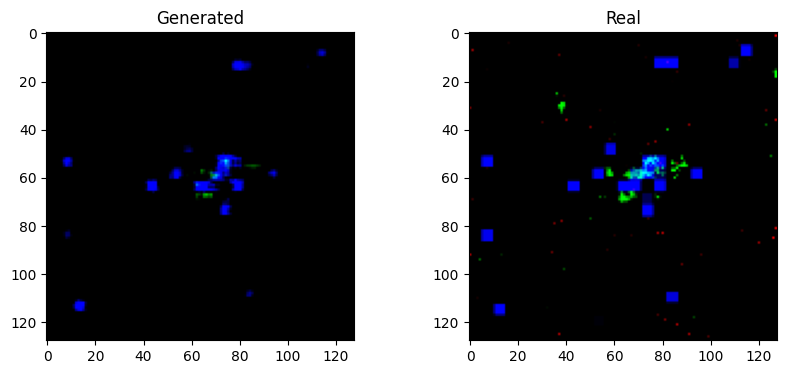

In [94]:
import matplotlib.pyplot as plt

fake_img = fake[0].cpu().permute(1, 2, 0)   # C,H,W → H,W,C
real_img = high_r.permute(1, 2, 0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Generated")
plt.imshow(fake_img)

plt.subplot(1,2,2)
plt.title("Real")
plt.imshow(real_img)

plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.47718394..1.7669327].


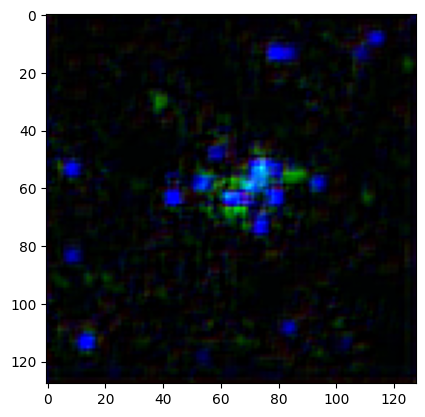

In [91]:
fake_img = fake[0].cpu().permute(1, 2, 0)

# [-1,1] → [0,1]
fake_img = (fake_img + 1) / 2

plt.imshow(fake_img)
plt.show()

In [87]:
!pip install torchviz -q

In [88]:
from torchviz import make_dot

device = "cuda" if torch.cuda.is_available() else "cpu"


sample_lr, _ = dataset[0]
dim = sample_lr.shape[0]

G = Generator(dim, dim).to(device)


x = torch.randn(1, dim, 64, 64).to(device)


y = G(x)


dot = make_dot(y, params=dict(G.named_parameters()))

dot.render("generator_architecture", format="png")

'generator_architecture.png'

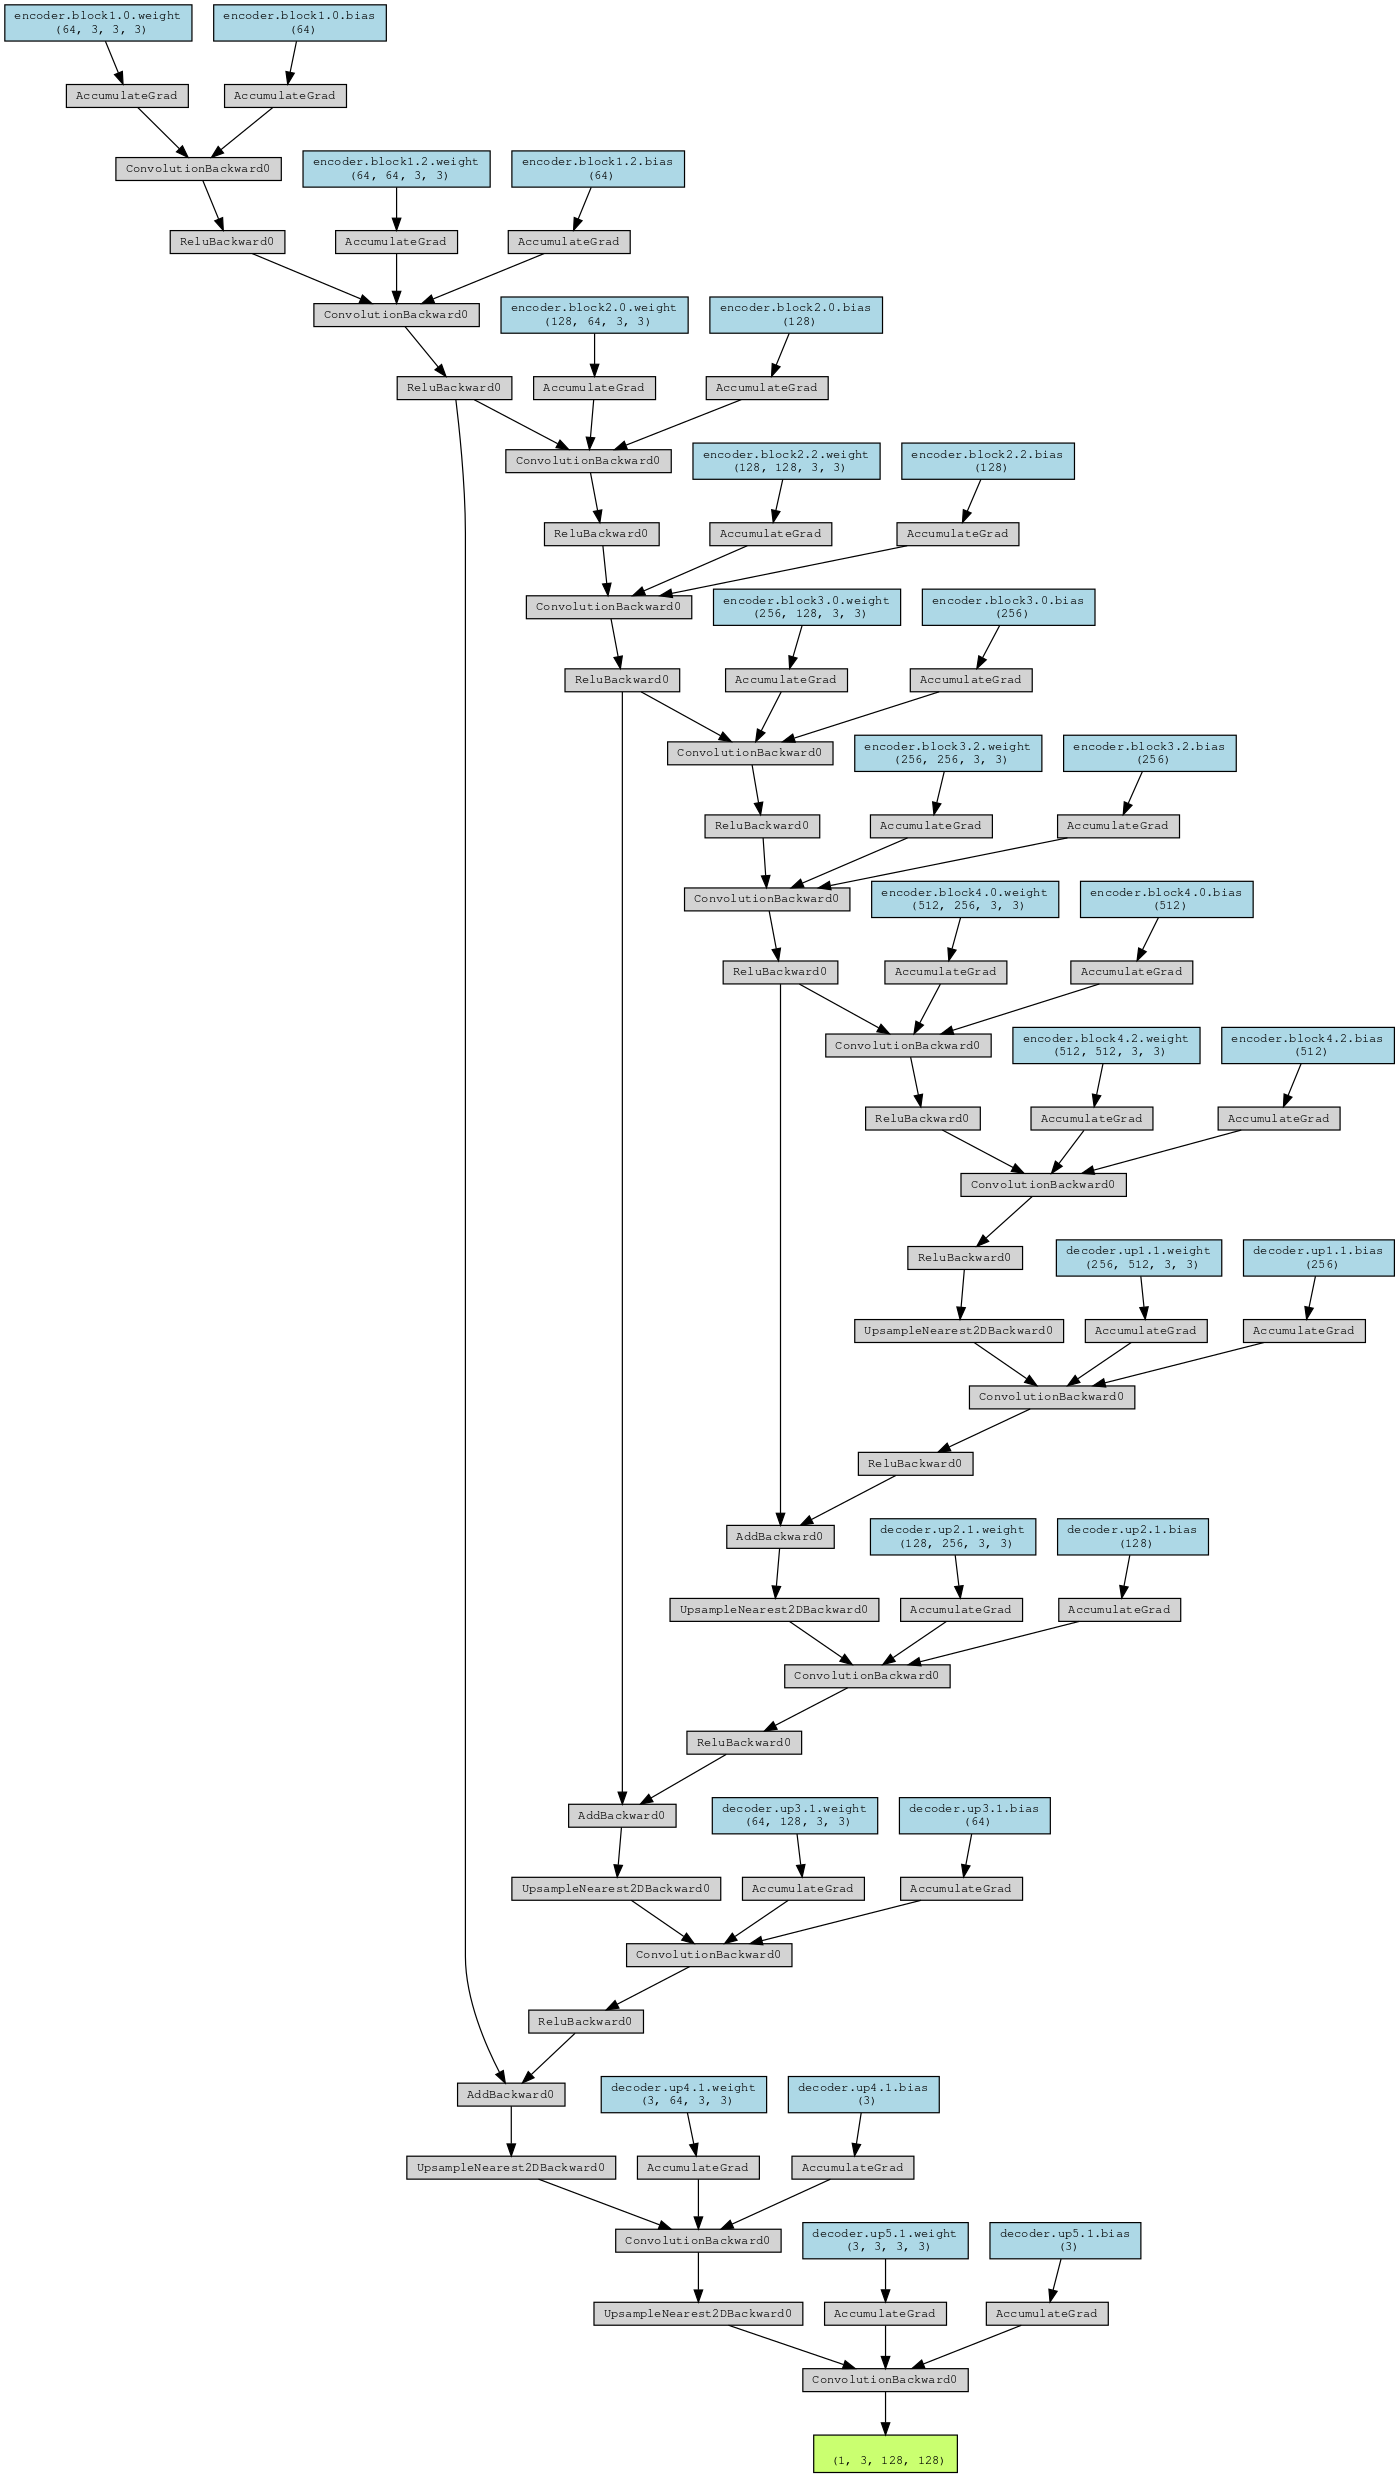

In [89]:
from IPython.display import Image
Image("generator_architecture.png")